Training OR Gate
Epoch 1 | Update 1:
  Input: [0 1], Target: 1, Prediction: 0
  New Weights: [0.  0.1], New Bias: 0.10


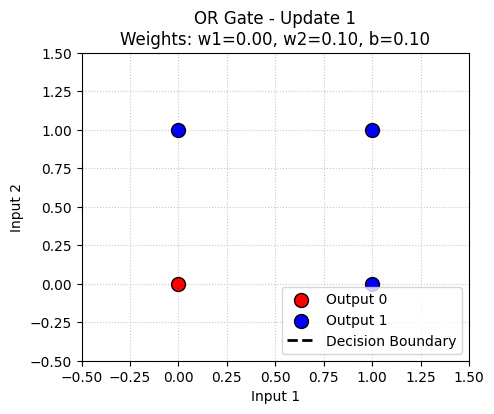

Epoch 2 | Update 2:
  Input: [0 0], Target: 0, Prediction: 1
  New Weights: [0.  0.1], New Bias: 0.00


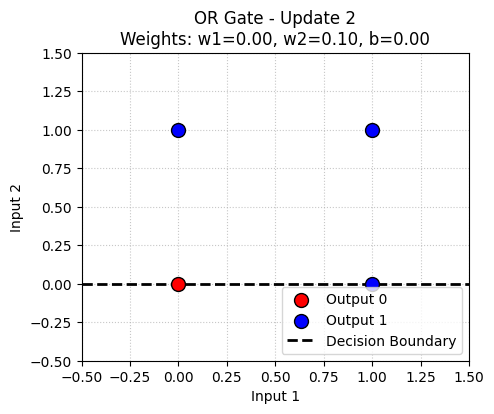

Epoch 2 | Update 3:
  Input: [1 0], Target: 1, Prediction: 0
  New Weights: [0.1 0.1], New Bias: 0.10


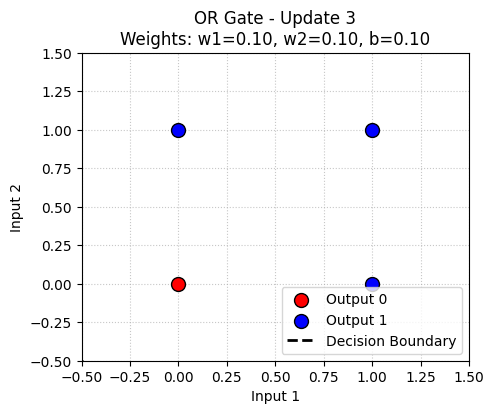

Epoch 3 | Update 4:
  Input: [0 0], Target: 0, Prediction: 1
  New Weights: [0.1 0.1], New Bias: 0.00


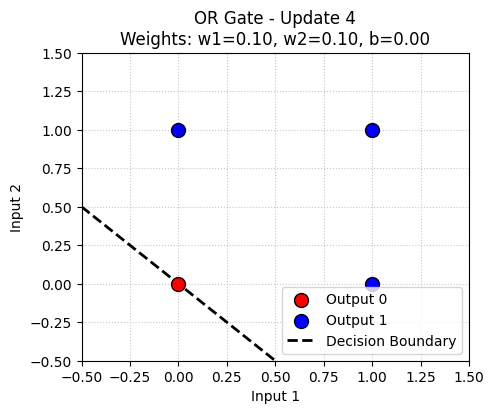


=> OR Gate converged perfectly after 4 epochs.

Training NOT Gate
Epoch 1 | Update 1:
  Input: [0], Target: 1, Prediction: 0
  New Weights: [0.], New Bias: 0.10


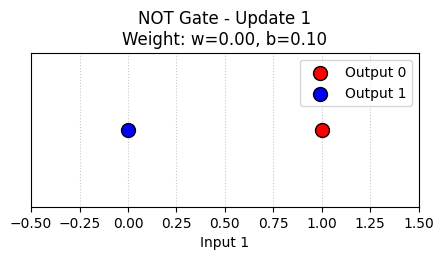

Epoch 1 | Update 2:
  Input: [1], Target: 0, Prediction: 1
  New Weights: [-0.1], New Bias: 0.00


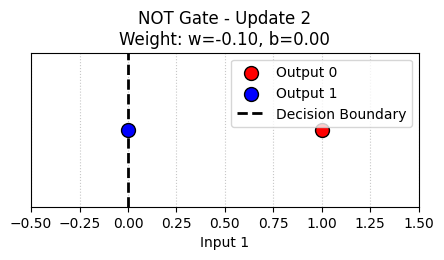

Epoch 2 | Update 3:
  Input: [0], Target: 1, Prediction: 0
  New Weights: [-0.1], New Bias: 0.10


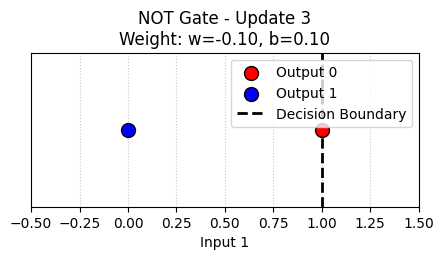


=> NOT Gate converged perfectly after 3 epochs.

Training AND Gate
Epoch 1 | Update 1:
  Input: [1 1], Target: 1, Prediction: 0
  New Weights: [0.1 0.1], New Bias: 0.10


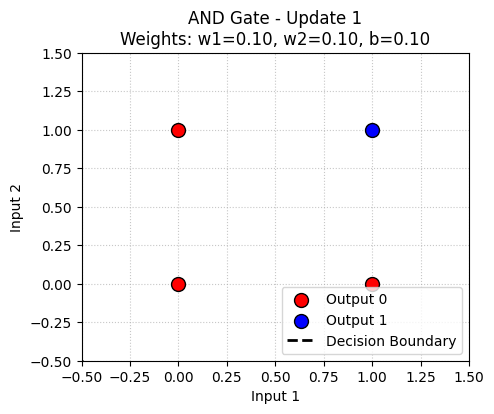

Epoch 2 | Update 2:
  Input: [0 0], Target: 0, Prediction: 1
  New Weights: [0.1 0.1], New Bias: 0.00


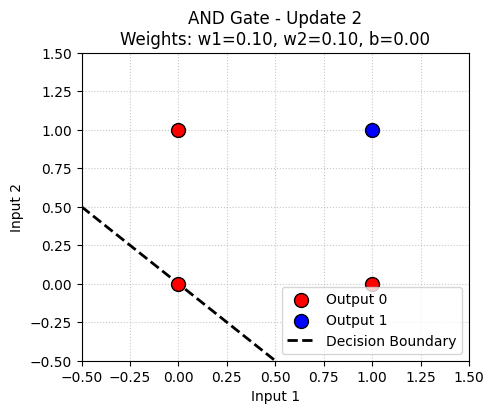

Epoch 2 | Update 3:
  Input: [0 1], Target: 0, Prediction: 1
  New Weights: [0.1 0. ], New Bias: -0.10


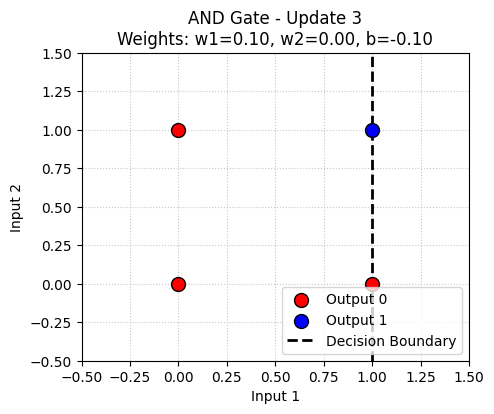

Epoch 2 | Update 4:
  Input: [1 1], Target: 1, Prediction: 0
  New Weights: [0.2 0.1], New Bias: 0.00


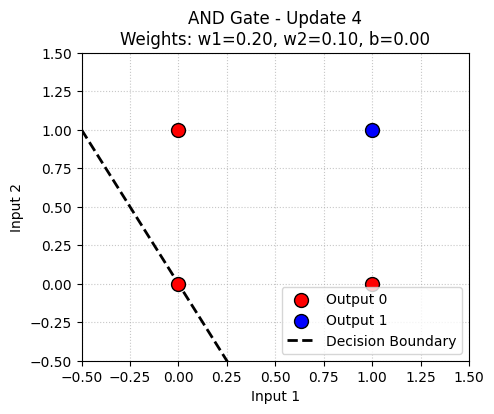

Epoch 3 | Update 5:
  Input: [0 1], Target: 0, Prediction: 1
  New Weights: [0.2 0. ], New Bias: -0.10


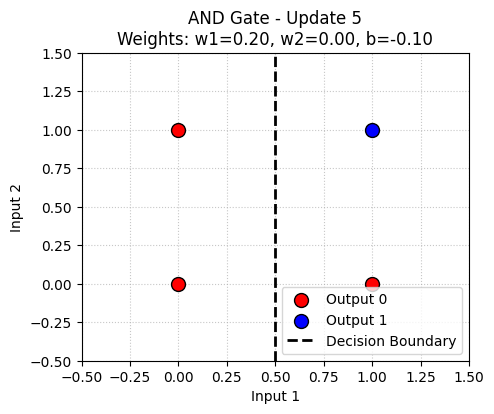

Epoch 3 | Update 6:
  Input: [1 0], Target: 0, Prediction: 1
  New Weights: [0.1 0. ], New Bias: -0.20


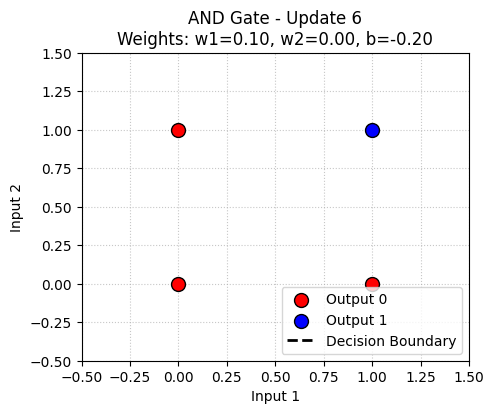

Epoch 3 | Update 7:
  Input: [1 1], Target: 1, Prediction: 0
  New Weights: [0.2 0.1], New Bias: -0.10


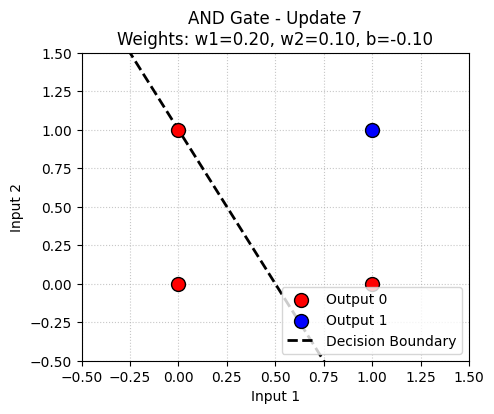

Epoch 4 | Update 8:
  Input: [1 0], Target: 0, Prediction: 1
  New Weights: [0.1 0.1], New Bias: -0.20


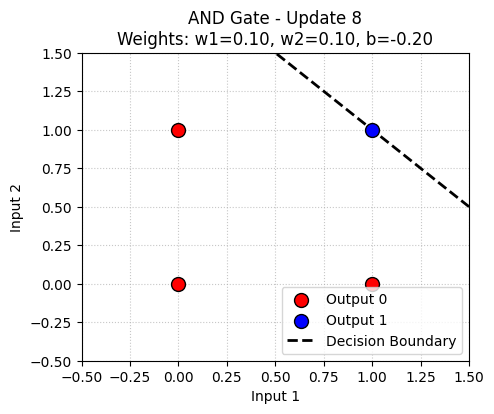

Epoch 4 | Update 9:
  Input: [1 1], Target: 1, Prediction: 0
  New Weights: [0.2 0.2], New Bias: -0.10


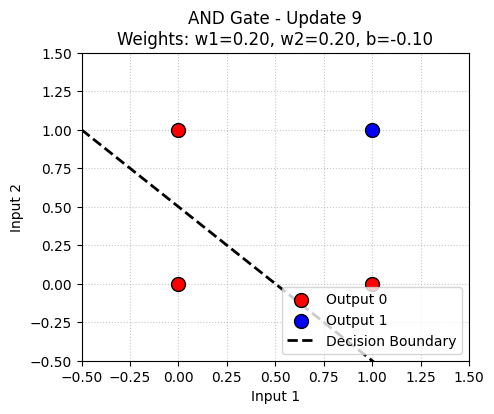

Epoch 5 | Update 10:
  Input: [0 1], Target: 0, Prediction: 1
  New Weights: [0.2 0.1], New Bias: -0.20


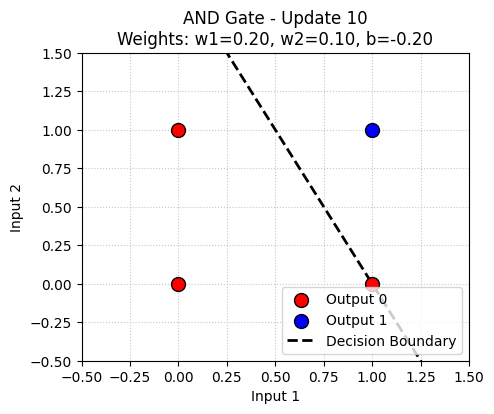


=> AND Gate converged perfectly after 6 epochs.



In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Activation Function
# ---------------------------------------------------------
def step_function(z):
    """Step activation function: returns 1 if z >= 0, else 0."""
    return 1 if z > 0 else 0

# ---------------------------------------------------------
# 2. Plotting Functions
# ---------------------------------------------------------
def plot_decision_boundary_2d(X, Y, w, b, gate_name, update_idx):
    """Plots the decision boundary for 2D inputs (AND, OR)."""
    plt.figure(figsize=(5, 4))

    # Scatter plot for classes
    plt.scatter(X[Y == 0][:, 0], X[Y == 0][:, 1], color='red', label='Output 0', s=100, edgecolors='k', zorder=3)
    plt.scatter(X[Y == 1][:, 0], X[Y == 1][:, 1], color='blue', label='Output 1', s=100, edgecolors='k', zorder=3)

    # Decision boundary parameters
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5

    # The decision boundary equation is: w1*x1 + w2*x2 + b = 0
    if w[1] != 0:
        # Solve for x2: x2 = -(w1*x1 + b) / w2
        x_vals = np.array([x_min, x_max])
        y_vals = -(w[0] * x_vals + b) / w[1]
        plt.plot(x_vals, y_vals, 'k--', linewidth=2, label='Decision Boundary')
    elif w[0] != 0:
        # Vertical line: x1 = -b / w1
        x_val = -b / w[0]
        plt.axvline(x=x_val, color='k', linestyle='--', linewidth=2, label='Decision Boundary')

    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.title(f"{gate_name} Gate - Update {update_idx}\nWeights: w1={w[0]:.2f}, w2={w[1]:.2f}, b={b:.2f}")
    plt.xlabel("Input 1")
    plt.ylabel("Input 2")
    plt.legend(loc='lower right')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

def plot_decision_boundary_1d(X, Y, w, b, gate_name, update_idx):
    """Plots the decision boundary for 1D inputs (NOT)."""
    plt.figure(figsize=(5, 2))

    # Scatter plot for classes on the x-axis (y=0)
    plt.scatter(X[Y == 0], np.zeros(sum(Y == 0)), color='red', label='Output 0', s=100, edgecolors='k', zorder=3)
    plt.scatter(X[Y == 1], np.zeros(sum(Y == 1)), color='blue', label='Output 1', s=100, edgecolors='k', zorder=3)

    # The decision boundary equation is: w*x + b = 0 => x = -b/w
    if w[0] != 0:
        x_val = -b / w[0]
        plt.axvline(x=x_val, color='k', linestyle='--', linewidth=2, label='Decision Boundary')

    plt.xlim(-0.5, 1.5)
    plt.yticks([]) # Hide y-axis since it's 1D
    plt.title(f"{gate_name} Gate - Update {update_idx}\nWeight: w={w[0]:.2f}, b={b:.2f}")
    plt.xlabel("Input 1")
    plt.legend(loc='upper right')
    plt.grid(axis='x', linestyle=':', alpha=0.7)
    plt.show()

# ---------------------------------------------------------
# 3. Perceptron Training Algorithm
# ---------------------------------------------------------
def train_perceptron(X, Y, gate_name, lr=0.1, epochs=10):
    n_features = X.shape[1]

    # Initialize weights and bias to zeros
    w = np.zeros(n_features)
    b = 0.0
    update_count = 0

    print("="*50)
    print(f"Training {gate_name} Gate")
    print("="*50)

    for epoch in range(epochs):
        errors = 0
        for i in range(len(X)):
            # Forward pass: z = W.X + b
            z = np.dot(X[i], w) + b
            y_pred = step_function(z)

            # Calculate error
            error = Y[i] - y_pred

            # If there's an error, update weights and plot
            if error != 0:
                w = w + lr * error * X[i]
                b = b + lr * error

                update_count += 1
                errors += 1

                print(f"Epoch {epoch+1} | Update {update_count}:")
                print(f"  Input: {X[i]}, Target: {Y[i]}, Prediction: {y_pred}")
                print(f"  New Weights: {w}, New Bias: {b:.2f}")

                # Plot based on dimensionality
                if n_features == 2:
                    plot_decision_boundary_2d(X, Y, w, b, gate_name, update_count)
                else:
                    plot_decision_boundary_1d(X, Y, w, b, gate_name, update_count)

        # Stop training if converged (no errors in an epoch)
        if errors == 0:
            print(f"\n=> {gate_name} Gate converged perfectly after {epoch+1} epochs.\n")
            break

# ---------------------------------------------------------
# 4. Define Datasets and Execute
# ---------------------------------------------------------

# OR Gate Data
X_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y_or = np.array([0, 1, 1, 1])

# AND Gate Data
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y_and = np.array([0, 0, 0, 1])

# NOT Gate Data
X_not = np.array([[0], [1]])
Y_not = np.array([1, 0])

# Train and plot all gates
train_perceptron(X_or, Y_or, gate_name="OR")
train_perceptron(X_not, Y_not, gate_name="NOT")
train_perceptron(X_and, Y_and, gate_name="AND")

Training OR Gate & Recording Updates
Epoch 1 | Update  1: Input [0 1] -> Target 1 | Weights: [0.  0.1], Bias: 0.10
Epoch 2 | Update  2: Input [0 0] -> Target 0 | Weights: [0.  0.1], Bias: 0.00
Epoch 2 | Update  3: Input [1 0] -> Target 1 | Weights: [0.1 0.1], Bias: 0.10
Epoch 3 | Update  4: Input [0 0] -> Target 0 | Weights: [0.1 0.1], Bias: 0.00

=> OR Gate converged perfectly after 4 epochs.



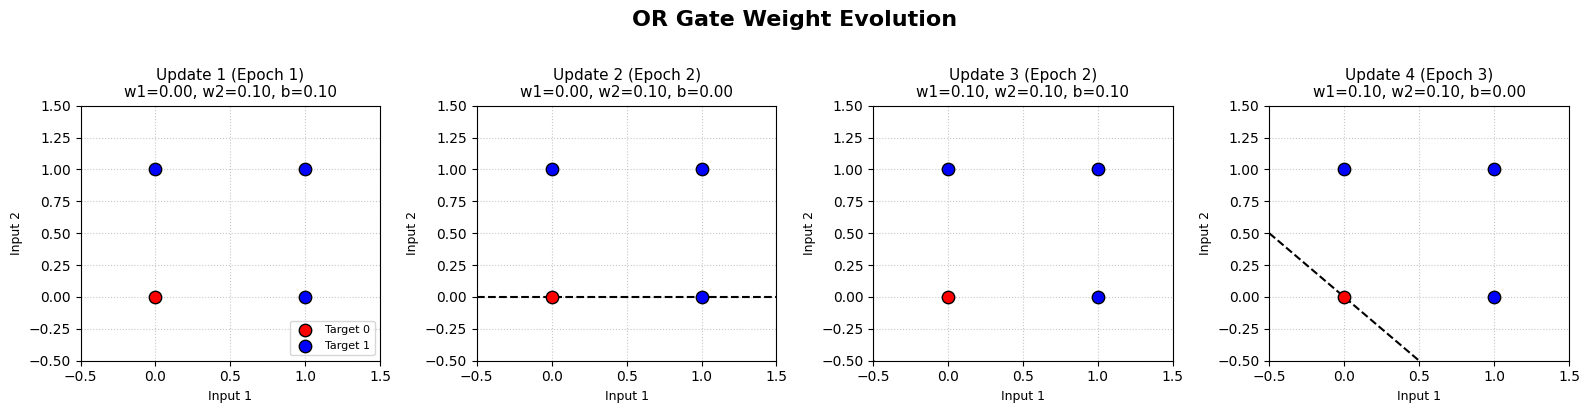

Training NOT Gate & Recording Updates
Epoch 1 | Update  1: Input [0] -> Target 1 | Weights: [0.], Bias: 0.10
Epoch 1 | Update  2: Input [1] -> Target 0 | Weights: [-0.1], Bias: 0.00
Epoch 2 | Update  3: Input [0] -> Target 1 | Weights: [-0.1], Bias: 0.10

=> NOT Gate converged perfectly after 3 epochs.



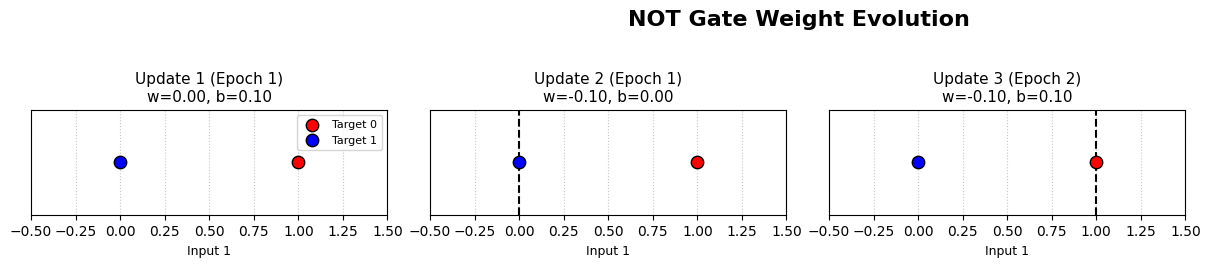

Training AND Gate & Recording Updates
Epoch 1 | Update  1: Input [1 1] -> Target 1 | Weights: [0.1 0.1], Bias: 0.10
Epoch 2 | Update  2: Input [0 0] -> Target 0 | Weights: [0.1 0.1], Bias: 0.00
Epoch 2 | Update  3: Input [0 1] -> Target 0 | Weights: [0.1 0. ], Bias: -0.10
Epoch 2 | Update  4: Input [1 1] -> Target 1 | Weights: [0.2 0.1], Bias: 0.00
Epoch 3 | Update  5: Input [0 1] -> Target 0 | Weights: [0.2 0. ], Bias: -0.10
Epoch 3 | Update  6: Input [1 0] -> Target 0 | Weights: [0.1 0. ], Bias: -0.20
Epoch 3 | Update  7: Input [1 1] -> Target 1 | Weights: [0.2 0.1], Bias: -0.10
Epoch 4 | Update  8: Input [1 0] -> Target 0 | Weights: [0.1 0.1], Bias: -0.20
Epoch 4 | Update  9: Input [1 1] -> Target 1 | Weights: [0.2 0.2], Bias: -0.10
Epoch 5 | Update 10: Input [0 1] -> Target 0 | Weights: [0.2 0.1], Bias: -0.20

=> AND Gate converged perfectly after 6 epochs.



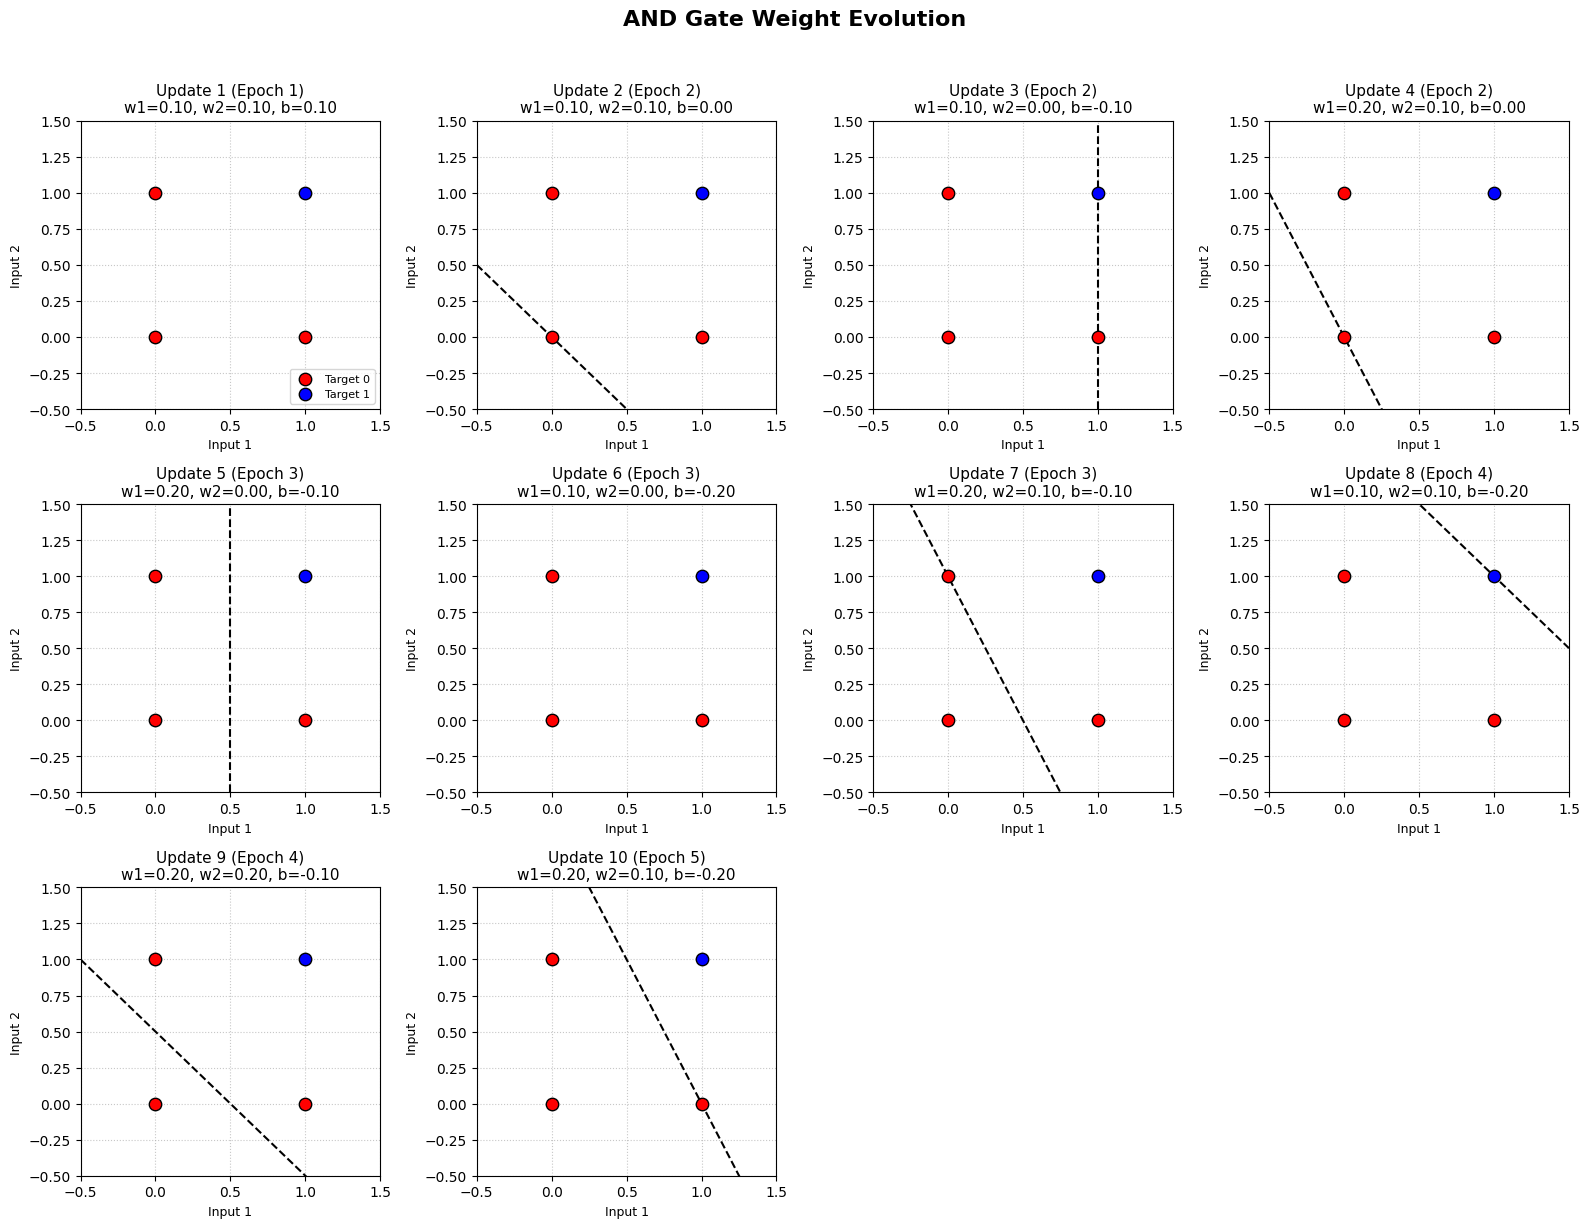

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import math

# ---------------------------------------------------------
# 1. Activation Function
# ---------------------------------------------------------
def step_function(z):
    """Step activation function: returns 1 if z > 0, else 0."""
    return 1 if z > 0 else 0

# ---------------------------------------------------------
# 2. Training Algorithm (Saves History)
# ---------------------------------------------------------
def train_and_record(X, Y, gate_name, lr=0.1, max_epochs=10):
    """Trains the perceptron and records the state after every update."""
    n_features = X.shape[1]
    w = np.zeros(n_features)
    b = 0.0
    update_count = 0
    history = []

    print("="*60)
    print(f"Training {gate_name} Gate & Recording Updates")
    print("="*60)

    for epoch in range(max_epochs):
        errors = 0
        for i in range(len(X)):
            z = np.dot(X[i], w) + b
            y_pred = step_function(z)

            error = Y[i] - y_pred

            if error != 0:
                w = w + lr * error * X[i]
                b = b + lr * error

                update_count += 1
                errors += 1

                # Save state for the grid plot
                history.append({
                    'epoch': epoch + 1,
                    'update': update_count,
                    'w': w.copy(),
                    'b': b
                })

                # Print to console
                print(f"Epoch {epoch+1} | Update {update_count:2d}: Input {X[i]} -> Target {Y[i]} | Weights: {w}, Bias: {b:.2f}")

        if errors == 0:
            print(f"\n=> {gate_name} Gate converged perfectly after {epoch+1} epochs.\n")
            break

    return history, X, Y

# ---------------------------------------------------------
# 3. Grid Plotting Functions
# ---------------------------------------------------------
def plot_grid_2d(history, X, Y, gate_name):
    """Plots a 4-column grid for 2D inputs (OR, AND)."""
    n_plots = len(history)
    if n_plots == 0:
        print(f"No updates required for {gate_name}. Weights already optimal.")
        return

    cols = 4
    rows = math.ceil(n_plots / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    # Ensure axes is always iterable even if there's only 1 row
    if rows == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for i, record in enumerate(history):
        ax = axes[i]
        w = record['w']
        b = record['b']

        # Scatter plot classes
        ax.scatter(X[Y == 0][:, 0], X[Y == 0][:, 1], color='red', label='Target 0', s=80, edgecolors='k', zorder=3)
        ax.scatter(X[Y == 1][:, 0], X[Y == 1][:, 1], color='blue', label='Target 1', s=80, edgecolors='k', zorder=3)

        x_min, x_max = -0.5, 1.5
        y_min, y_max = -0.5, 1.5

        # Draw Decision Boundary (if weights are not completely zero)
        if w[1] != 0:
            x_vals = np.array([x_min, x_max])
            y_vals = -(w[0] * x_vals + b) / w[1]
            ax.plot(x_vals, y_vals, 'k--', linewidth=1.5)
        elif w[0] != 0:
            ax.axvline(x=-b / w[0], color='k', linestyle='--', linewidth=1.5)

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_title(f"Update {record['update']} (Epoch {record['epoch']})\nw1={w[0]:.2f}, w2={w[1]:.2f}, b={b:.2f}", fontsize=11)
        ax.set_xlabel("Input 1", fontsize=9)
        ax.set_ylabel("Input 2", fontsize=9)
        ax.grid(True, linestyle=':', alpha=0.7)

        if i == 0:
            ax.legend(loc='lower right', fontsize=8)

    # Hide empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f"{gate_name} Gate Weight Evolution", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f"{gate_name.lower()}_updates_grid.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_grid_1d(history, X, Y, gate_name):
    """Plots a 4-column grid for 1D inputs (NOT)."""
    n_plots = len(history)
    if n_plots == 0:
        return

    cols = 4
    rows = math.ceil(n_plots / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(16, 2.5 * rows))
    if rows == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for i, record in enumerate(history):
        ax = axes[i]
        w = record['w']
        b = record['b']

        # Scatter plot classes on x-axis
        ax.scatter(X[Y == 0], np.zeros(sum(Y == 0)), color='red', label='Target 0', s=80, edgecolors='k', zorder=3)
        ax.scatter(X[Y == 1], np.zeros(sum(Y == 1)), color='blue', label='Target 1', s=80, edgecolors='k', zorder=3)

        # Draw Decision Boundary for 1D
        if w[0] != 0:
            x_val = -b / w[0]
            ax.axvline(x=x_val, color='k', linestyle='--', linewidth=1.5)

        ax.set_xlim(-0.5, 1.5)
        ax.set_yticks([]) # Hide Y-axis for 1D
        ax.set_title(f"Update {record['update']} (Epoch {record['epoch']})\nw={w[0]:.2f}, b={b:.2f}", fontsize=11)
        ax.set_xlabel("Input 1", fontsize=9)
        ax.grid(axis='x', linestyle=':', alpha=0.7)

        if i == 0:
            ax.legend(loc='upper right', fontsize=8)

    # Hide empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f"{gate_name} Gate Weight Evolution", fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig(f"{gate_name.lower()}_updates_grid.png", dpi=300, bbox_inches='tight')
    plt.show()

# ---------------------------------------------------------
# 4. Define Datasets and Execute Pipeline
# ---------------------------------------------------------

# OR Gate
X_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y_or = np.array([0, 1, 1, 1])
hist_or, _, _ = train_and_record(X_or, Y_or, gate_name="OR")
plot_grid_2d(hist_or, X_or, Y_or, gate_name="OR")

# NOT Gate
X_not = np.array([[0], [1]])
Y_not = np.array([1, 0])
hist_not, _, _ = train_and_record(X_not, Y_not, gate_name="NOT")
plot_grid_1d(hist_not, X_not, Y_not, gate_name="NOT")

# AND Gate
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y_and = np.array([0, 0, 0, 1])
hist_and, _, _ = train_and_record(X_and, Y_and, gate_name="AND")
plot_grid_2d(hist_and, X_and, Y_and, gate_name="AND")